# Brain Tumor MRI Classification (Colab)

Lawson Darrow & Nikiraj Konwar

## What this notebook includes
- Data download from Kaggle (`masoudnickparvar/brain-tumor-mri-dataset`)
- Stratified train/validation split from `Training/`, held-out `Testing/` for final metrics
- Classical baselines (Logistic Regression, RBF SVM, Random Forest) on HOG + PCA features
- Custom CNN training and evaluation
- Two-stage transfer learning (head warmup + partial fine-tuning)
- Final model comparison table and visualization

## Notes
- Run cells top-to-bottom.
- Artifacts are written to `/content/results`.

In [1]:
# Colab dependency setup (safe to re-run)
!pip -q install kagglehub scikit-image seaborn tqdm

In [2]:
from pathlib import Path

# -----------------------------
# Experiment configuration block
# -----------------------------

# Fixed seed for reproducibility.
SEED = 42

# Validation fraction sampled from Training/.
VAL_SIZE = 0.15

# Image size used by CNN and transfer models.
IMAGE_SIZE = 224

# Batch size for DataLoaders.
BATCH_SIZE = 32

# Epoch budget for deep-learning stages.
EPOCHS = 3

# Transfer model backbone selection.
TRANSFER_MODEL = "resnet50"  # options: resnet50, efficientnet_b0, vgg16

# Kaggle dataset identifier.
DATASET_SLUG = "masoudnickparvar/brain-tumor-mri-dataset"

# Root folder for generated artifacts in Colab.
RESULTS_ROOT = Path("/content/results")

In [3]:
# Standard library imports
import json
import os
import random
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Callable

# Third-party imports
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display
from PIL import Image
from sklearn.model_selection import StratifiedShuffleSplit
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.notebook import tqdm


def set_global_seed(seed: int = 42) -> None:
    """Set seeds and deterministic flags for reproducible experiments."""
    # Seed Python and NumPy randomness.
    random.seed(seed)
    np.random.seed(seed)

    # Seed PyTorch randomness on CPU and CUDA.
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Force deterministic convolution behavior where possible.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)


def ensure_dir(path: str | Path) -> Path:
    """Create directory if missing and return Path object."""
    path_obj = Path(path)
    path_obj.mkdir(parents=True, exist_ok=True)
    return path_obj


def save_json(data: dict[str, Any], out_path: str | Path) -> None:
    """Write formatted UTF-8 JSON with parent directory creation."""
    out_file = Path(out_path)

    # Make sure parent folders exist before writing.
    out_file.parent.mkdir(parents=True, exist_ok=True)

    # Persist readable JSON for easy grading/review.
    out_file.write_text(json.dumps(data, indent=2), encoding="utf-8")


# Initialize run state once at notebook startup.
set_global_seed(SEED)
RESULTS_ROOT = ensure_dir(RESULTS_ROOT)
print(f"Using device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"Results directory: {RESULTS_ROOT}")

Using device: cuda
Results directory: /content/results


In [4]:
# Download dataset from Kaggle using the slug from config.
# The first run may request Kaggle authentication.
download_root = Path(kagglehub.dataset_download(DATASET_SLUG))


def resolve_dataset_root(base_path: Path) -> Path:
    """Find the folder that contains both Training/ and Testing/."""
    # Fast path: dataset is already in expected layout.
    if (base_path / "Training").exists() and (base_path / "Testing").exists():
        return base_path

    # Search nested directories for a valid pair.
    candidates: list[Path] = []
    for training_dir in base_path.rglob("Training"):
        parent = training_dir.parent
        if (parent / "Testing").exists():
            candidates.append(parent)

    # Stop early with a clear message if no valid structure is found.
    if not candidates:
        raise FileNotFoundError(
            f"Could not find dataset root with Training/ and Testing/ under {base_path}"
        )

    # Prefer the shortest candidate path when multiple matches exist.
    candidates = sorted(candidates, key=lambda p: len(str(p)))
    return candidates[0]


# Resolve and print the final dataset root used below.
DATASET_ROOT = resolve_dataset_root(download_root)
print(f"Downloaded dataset cache root: {download_root}")
print(f"Using dataset root: {DATASET_ROOT}")

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Downloaded dataset cache root: /kaggle/input/brain-tumor-mri-dataset
Using dataset root: /kaggle/input/brain-tumor-mri-dataset


In [5]:
# Accepted image file suffixes when scanning folders.
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


@dataclass(frozen=True)
class SplitDataFrames:
    # Stratified training split used for model fitting.
    train: pd.DataFrame
    # Validation split sampled from Training/ only.
    val: pd.DataFrame
    # Official held-out test split from Testing/.
    test: pd.DataFrame
    # Stable class order used for reports and confusion matrices.
    class_names: list[str]


def _collect_split_records(split_dir: Path) -> list[dict[str, str | int]]:
    # Fail fast if an expected split folder is missing.
    if not split_dir.exists():
        raise FileNotFoundError(f"Split directory not found: {split_dir}")

    # Sort class directories for deterministic label IDs.
    class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])
    records: list[dict[str, str | int]] = []

    # Assign integer labels based on sorted class order.
    for class_idx, class_dir in enumerate(class_dirs):
        # rglob supports nested folder layouts under each class.
        for image_path in class_dir.rglob("*"):
            if image_path.suffix.lower() in IMAGE_EXTENSIONS:
                records.append(
                    {
                        "path": str(image_path),
                        "class_name": class_dir.name,
                        "label": class_idx,
                    }
                )
    return records


def load_dataset_frames(
    dataset_root: str | Path,
    val_size: float = 0.15,
    random_seed: int = 42,
) -> SplitDataFrames:
    """Load Training/Testing directories and create stratified validation split."""
    dataset_root = Path(dataset_root)
    train_root = dataset_root / "Training"
    test_root = dataset_root / "Testing"

    # Build per-image records for both official splits.
    train_records = _collect_split_records(train_root)
    test_records = _collect_split_records(test_root)

    # Guard against partially downloaded or malformed datasets.
    if not train_records or not test_records:
        raise ValueError("Training and Testing folders must both contain labeled images.")

    full_train_df = pd.DataFrame(train_records)
    test_df = pd.DataFrame(test_records)

    # Derive a stable class map so train/test labels align perfectly.
    class_names = sorted(full_train_df["class_name"].unique().tolist())
    class_to_label = {name: i for i, name in enumerate(class_names)}

    full_train_df["label"] = full_train_df["class_name"].map(class_to_label)
    test_df["label"] = test_df["class_name"].map(class_to_label)

    # Create a stratified validation set from Training/ only.
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=val_size, random_state=random_seed)
    train_idx, val_idx = next(splitter.split(full_train_df["path"], full_train_df["label"]))

    train_df = full_train_df.iloc[train_idx].reset_index(drop=True)
    val_df = full_train_df.iloc[val_idx].reset_index(drop=True)

    return SplitDataFrames(train=train_df, val=val_df, test=test_df, class_names=class_names)


class BrainTumorImageDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform: Callable | None = None) -> None:
        # Reset index so positional indexing is always contiguous.
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        # Read RGB tensors for CNN and transfer models.
        row = self.frame.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")

        # Apply augmentation/normalization pipeline if configured.
        if self.transform is not None:
            image = self.transform(image)

        return image, int(row["label"])


def build_transforms(image_size: int = 224) -> tuple[Callable, Callable]:
    # Training transform includes mild augmentation for robustness.
    train_transform = transforms.Compose(
        [
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.08, contrast=0.08),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )

    # Evaluation transform skips augmentation to keep metrics stable.
    eval_transform = transforms.Compose(
        [
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )

    return train_transform, eval_transform


def create_dataloaders(
    split_frames: SplitDataFrames,
    image_size: int = 224,
    batch_size: int = 32,
    num_workers: int = 2,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    # Build transform pipelines once and reuse per split.
    train_tf, eval_tf = build_transforms(image_size=image_size)

    # Wrap each dataframe split in a PyTorch Dataset.
    train_dataset = BrainTumorImageDataset(split_frames.train, transform=train_tf)
    val_dataset = BrainTumorImageDataset(split_frames.val, transform=eval_tf)
    test_dataset = BrainTumorImageDataset(split_frames.test, transform=eval_tf)

    # Shuffle only training batches.
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    return train_loader, val_loader, test_loader

In [6]:
def class_distribution(frame: pd.DataFrame, class_names: list[str]) -> dict[str, int]:
    # Raw counts per class from the dataframe.
    counts = frame["class_name"].value_counts().to_dict()

    # Return counts in fixed class order.
    return {name: int(counts.get(name, 0)) for name in class_names}


# Build train/val/test frames from the canonical folder structure.
split_frames = load_dataset_frames(
    dataset_root=DATASET_ROOT,
    val_size=VAL_SIZE,
    random_seed=SEED,
)

# Pack split metadata into a JSON-friendly dict.
split_report = {
    "class_names": split_frames.class_names,
    "train_size": int(len(split_frames.train)),
    "validation_size": int(len(split_frames.val)),
    "test_size": int(len(split_frames.test)),
    "train_class_distribution": class_distribution(split_frames.train, split_frames.class_names),
    "validation_class_distribution": class_distribution(split_frames.val, split_frames.class_names),
    "test_class_distribution": class_distribution(split_frames.test, split_frames.class_names),
}

# Save split stats for reproducibility and grading.
save_json(split_report, RESULTS_ROOT / "split_report.json")

# Display split summary as a single-row table.
display(Markdown("### Split Summary"))
display(pd.DataFrame([split_report]))

# Display class counts per split side-by-side.
display(Markdown("### Class Distribution"))
display(
    pd.DataFrame(
        {
            "train": split_report["train_class_distribution"],
            "validation": split_report["validation_class_distribution"],
            "test": split_report["test_class_distribution"],
        }
    )
)

### Split Summary

,class_names,train_size,validation_size,test_size,train_class_distribution,validation_class_distribution,test_class_distribution
0,"[glioma, meningioma, notumor, pituitary]",4760,840,1600,"{'glioma': 1190, 'meningioma': 1190, 'notumor'...","{'glioma': 210, 'meningioma': 210, 'notumor': ...","{'glioma': 400, 'meningioma': 400, 'notumor': ..."


### Class Distribution

,train,validation,test
glioma,1190,210,400
meningioma,1190,210,400
notumor,1190,210,400
pituitary,1190,210,400


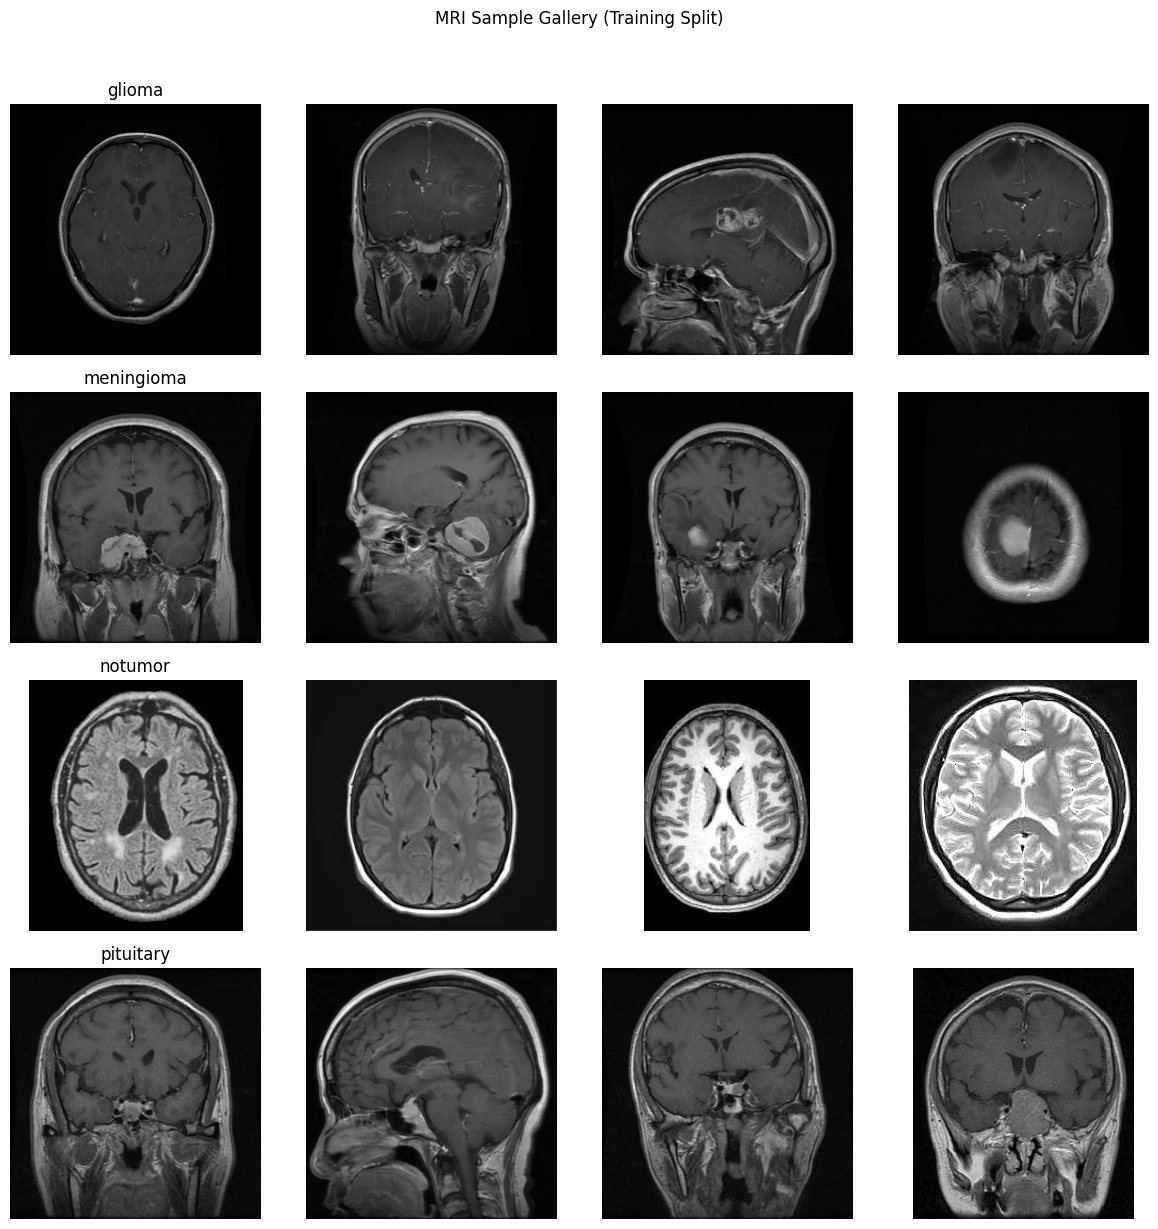

In [7]:
def show_sample_gallery(split_frames: SplitDataFrames, samples_per_class: int = 4) -> None:
    # Figure layout: one row per class, fixed columns per row.
    class_names = split_frames.class_names
    n_rows = len(class_names)
    n_cols = samples_per_class
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))

    # Normalize axes shape for the single-class edge case.
    if n_rows == 1:
        axes = np.array([axes])

    # Fill each row with examples from that class.
    for row_idx, class_name in enumerate(class_names):
        class_rows = split_frames.train[split_frames.train["class_name"] == class_name].head(samples_per_class)
        for col_idx in range(n_cols):
            ax = axes[row_idx, col_idx]
            ax.axis("off")

            # Draw image only when an example is available.
            if col_idx < len(class_rows):
                img = Image.open(class_rows.iloc[col_idx]["path"]).convert("RGB")
                ax.imshow(img)

                # Label class on the first column for quick scanning.
                if col_idx == 0:
                    ax.set_title(class_name)

    plt.suptitle("MRI Sample Gallery (Training Split)", y=1.02)
    plt.tight_layout()
    plt.show()


# Preview training examples before model training.
show_sample_gallery(split_frames)

In [8]:
# Classical ML + feature extraction imports.
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from skimage.feature import hog


def build_metrics_dict(y_true: list[int], y_pred: list[int], class_names: list[str]) -> dict[str, Any]:
    # Build standard classification metrics dictionary.
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    # Cast accuracy to float for consistent JSON output.
    report["accuracy"] = float(report["accuracy"])
    return report


def plot_confusion_matrix(
    y_true: list[int],
    y_pred: list[int],
    class_names: list[str],
    title: str,
) -> plt.Figure:
    # Compute raw confusion counts.
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))

    # Render labeled heatmap for easy error inspection.
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    fig.tight_layout()
    return fig

In [9]:
@dataclass
class FeatureConfig:
    # Resize value for handcrafted feature extraction.
    image_size: int = 128
    # Toggle HOG vs raw pixel flattening.
    use_hog: bool = True
    # HOG cell granularity.
    pixels_per_cell: int = 16
    # HOG block context.
    cells_per_block: int = 2
    # PCA projection size (None disables PCA).
    pca_components: int | None = 200


def _load_image_array(path: str, image_size: int = 128) -> np.ndarray:
    # Convert to grayscale for classical feature branch.
    image = Image.open(path).convert("L").resize((image_size, image_size))

    # Normalize to [0, 1] float range.
    return np.asarray(image, dtype=np.float32) / 255.0


def _extract_single_feature(image: np.ndarray, cfg: FeatureConfig) -> np.ndarray:
    # Use HOG descriptors when enabled.
    if cfg.use_hog:
        return hog(
            image,
            orientations=9,
            pixels_per_cell=(cfg.pixels_per_cell, cfg.pixels_per_cell),
            cells_per_block=(cfg.cells_per_block, cfg.cells_per_block),
            block_norm="L2-Hys",
            feature_vector=True,
        ).astype(np.float32)

    # Fallback to flattened pixel vector.
    return image.flatten().astype(np.float32)


def extract_feature_matrix(frame: pd.DataFrame, cfg: FeatureConfig) -> tuple[np.ndarray, np.ndarray]:
    # Accumulate one feature vector per image.
    features = []
    labels = frame["label"].astype(int).to_numpy()

    for path in frame["path"].tolist():
        image = _load_image_array(path, image_size=cfg.image_size)
        features.append(_extract_single_feature(image, cfg))

    # Stack into 2D matrix: [num_samples, num_features].
    x = np.vstack(features)
    return x, labels


def maybe_apply_pca(
    x_train: np.ndarray,
    x_val: np.ndarray,
    x_test: np.ndarray,
    pca_components: int | None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, PCA | None]:
    # Skip PCA when disabled.
    if pca_components is None:
        return x_train, x_val, x_test, None

    # Cap components to valid matrix dimensions.
    n_components = min(pca_components, x_train.shape[0], x_train.shape[1])
    pca = PCA(n_components=n_components, random_state=SEED)

    # Fit on train, then transform val/test.
    x_train_pca = pca.fit_transform(x_train)
    x_val_pca = pca.transform(x_val)
    x_test_pca = pca.transform(x_test)
    return x_train_pca, x_val_pca, x_test_pca, pca

In [10]:
def _macro_f1(metrics: dict[str, Any]) -> float:
    # Convenience accessor for model selection.
    return float(metrics["macro avg"]["f1-score"])


def run_baseline_experiments(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    class_names: list[str],
    output_dir: str | Path,
    feature_cfg: FeatureConfig | None = None,
) -> dict[str, Any]:
    # Fill defaults and ensure output directory exists.
    feature_cfg = feature_cfg or FeatureConfig()
    output_dir = ensure_dir(output_dir)

    # Build feature matrices for each split.
    x_train, y_train = extract_feature_matrix(train_df, feature_cfg)
    x_val, y_val = extract_feature_matrix(val_df, feature_cfg)
    x_test, y_test = extract_feature_matrix(test_df, feature_cfg)

    # Optional dimensionality reduction.
    x_train, x_val, x_test, pca = maybe_apply_pca(
        x_train, x_val, x_test, pca_components=feature_cfg.pca_components
    )

    # Candidate classical models.
    models_by_name = {
        "logistic_regression": Pipeline(
            [
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(max_iter=500)),
            ]
        ),
        "svm_rbf": Pipeline(
            [
                ("scaler", StandardScaler()),
                ("model", SVC(kernel="rbf", C=5.0, gamma="scale")),
            ]
        ),
        "random_forest": RandomForestClassifier(n_estimators=250, random_state=SEED),
    }

    # Summary payload written to baseline_metrics.json.
    summary: dict[str, Any] = {
        "feature_config": asdict(feature_cfg),
        "pca_components_used": None if pca is None else int(pca.n_components_),
        "models": {},
    }

    # Track best model using validation macro-F1.
    best_model_name = ""
    best_val_f1 = -1.0
    best_test_metrics: dict[str, Any] = {}

    for model_name, model in models_by_name.items():
        # Train on the train split only.
        model.fit(x_train, y_train)

        # Predict on validation and test splits.
        val_pred = model.predict(x_val)
        test_pred = model.predict(x_test)

        val_metrics = build_metrics_dict(y_val.tolist(), val_pred.tolist(), class_names)
        test_metrics = build_metrics_dict(y_test.tolist(), test_pred.tolist(), class_names)

        # Update best model checkpoint by validation macro-F1.
        val_f1 = _macro_f1(val_metrics)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_name = model_name
            best_test_metrics = test_metrics

        # Save and display confusion matrix for each baseline.
        fig = plot_confusion_matrix(
            y_test.tolist(),
            test_pred.tolist(),
            class_names,
            title=f"{model_name} Test Confusion Matrix",
        )
        fig.savefig(output_dir / f"{model_name}_test_confusion_matrix.png", dpi=150)
        plt.show()
        plt.close(fig)

        # Persist validation/test metrics for this model.
        summary["models"][model_name] = {
            "validation": val_metrics,
            "test": test_metrics,
        }

    # Save best-model fields used later in final comparison.
    summary["best_model_by_validation_macro_f1"] = best_model_name
    summary["best_model_test_metrics"] = best_test_metrics

    save_json(summary, output_dir / "baseline_metrics.json")
    return summary


def summarize_for_comparison(metrics: dict[str, Any]) -> dict[str, float]:
    # Normalize metric keys across model families.
    return {
        "accuracy": float(metrics["accuracy"]),
        "macro_precision": float(metrics["macro avg"]["precision"]),
        "macro_recall": float(metrics["macro avg"]["recall"]),
        "macro_f1": float(metrics["macro avg"]["f1-score"]),
    }

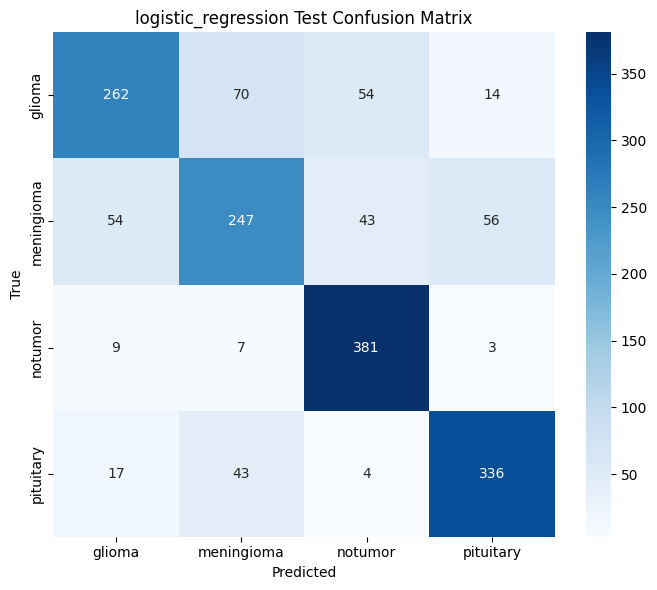

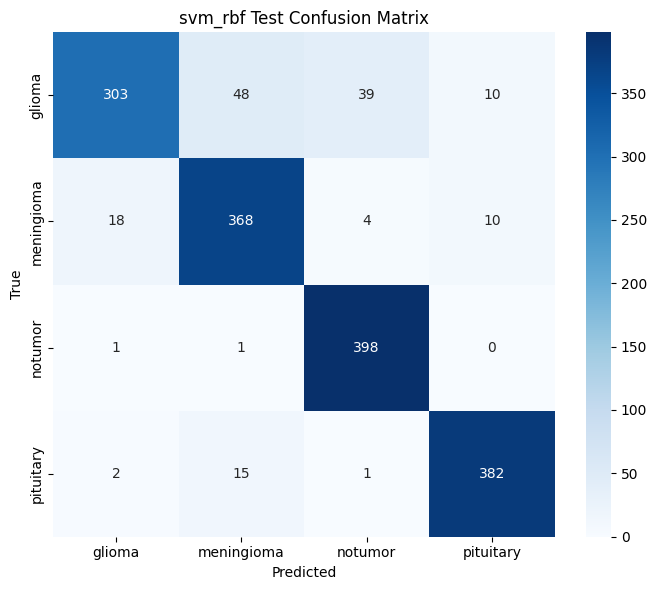

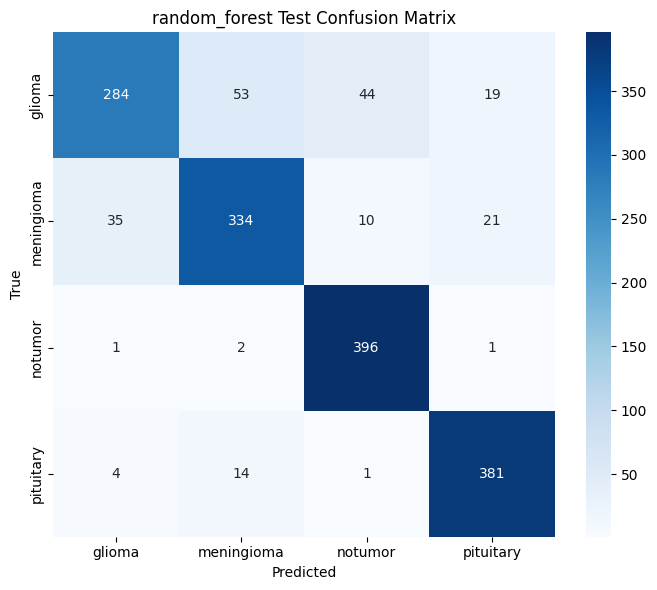

### Baseline Results (Test Metrics)

,model,accuracy,macro_precision,macro_recall,macro_f1,validation_macro_f1
1,baseline::svm_rbf,0.906875,0.909435,0.906875,0.904905,0.932310
2,baseline::random_forest,0.871875,0.871555,0.871875,0.868522,0.895527
0,baseline::logistic_regression,0.766250,0.762770,0.766250,0.761217,0.842981


Best baseline by validation macro-F1: baseline::svm_rbf


In [11]:
# Output location for handcrafted-feature baselines.
baseline_output_dir = ensure_dir(RESULTS_ROOT / "baselines")

# Baseline feature settings (HOG + PCA).
feature_cfg = FeatureConfig(image_size=128, use_hog=True, pca_components=200)

# Train and evaluate baseline models.
baseline_metrics = run_baseline_experiments(
    train_df=split_frames.train,
    val_df=split_frames.val,
    test_df=split_frames.test,
    class_names=split_frames.class_names,
    output_dir=baseline_output_dir,
    feature_cfg=feature_cfg,
)

# Build a compact table for quick review.
baseline_rows = []
for model_name, payload in baseline_metrics["models"].items():
    row = {
        "model": f"baseline::{model_name}",
        **summarize_for_comparison(payload["test"]),
        "validation_macro_f1": float(payload["validation"]["macro avg"]["f1-score"]),
    }
    baseline_rows.append(row)

baseline_df = pd.DataFrame(baseline_rows).sort_values("macro_f1", ascending=False)
display(Markdown("### Baseline Results (Test Metrics)"))
display(baseline_df)

# Pull best baseline fields for the final cross-model comparison.
best_baseline_name = baseline_metrics["best_model_by_validation_macro_f1"]
best_baseline_test_metrics = baseline_metrics["best_model_test_metrics"]
print(f"Best baseline by validation macro-F1: baseline::{best_baseline_name}")

# Initialize final comparison rows with the best baseline.
comparison_rows: list[dict[str, Any]] = []
comparison_rows.append(
    {
        "model": f"baseline::{best_baseline_name}",
        **summarize_for_comparison(best_baseline_test_metrics),
    }
)

In [12]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes: int, base_filters: int = 32, dropout: float = 0.35) -> None:
        super().__init__()

        # Convolutional backbone: progressively expands channels.
        self.features = nn.Sequential(
            nn.Conv2d(3, base_filters, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_filters),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(base_filters, base_filters * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_filters * 2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(base_filters * 2, base_filters * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_filters * 4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(base_filters * 4, base_filters * 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_filters * 8),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        # Classifier head: pooled features -> class logits.
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(base_filters * 8, base_filters * 4),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(base_filters * 4, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Feature extraction followed by final classifier head.
        x = self.features(x)
        return self.classifier(x)

In [13]:
def _run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer | None,
    device: torch.device,
) -> tuple[float, list[int], list[int]]:
    # Training mode when optimizer is provided.
    is_train = optimizer is not None
    model.train(is_train)

    # Running containers for loss and predictions.
    losses: list[float] = []
    all_preds: list[int] = []
    all_targets: list[int] = []

    for images, targets in tqdm(loader, leave=False):
        # Move batch tensors to active device.
        images = images.to(device)
        targets = targets.to(device)

        # Clear stale gradients before backprop.
        if is_train:
            optimizer.zero_grad()

        # Enable gradients only during training.
        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, targets)

            # Backpropagation + optimizer update.
            if is_train:
                loss.backward()
                optimizer.step()

        # Collect batch-level outputs for epoch metrics.
        losses.append(float(loss.item()))
        all_preds.extend(logits.argmax(dim=1).detach().cpu().tolist())
        all_targets.extend(targets.detach().cpu().tolist())

    avg_loss = float(sum(losses) / max(len(losses), 1))
    return avg_loss, all_targets, all_preds


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    class_names: list[str],
    output_dir: str | Path,
    epochs: int = 10,
    learning_rate: float = 1e-3,
    weight_decay: float = 1e-4,
    scheduler_patience: int = 2,
    early_stopping_patience: int = 6,
    min_delta: float = 1e-4,
) -> tuple[nn.Module, dict[str, Any]]:
    # Prepare output folder and active device.
    output_dir = ensure_dir(output_dir)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Core optimization components.
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=learning_rate,
        weight_decay=weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=scheduler_patience
    )

    # History structure used for plots and saved logs.
    history: dict[str, list[float]] = {
        "train_loss": [],
        "val_loss": [],
        "train_macro_f1": [],
        "val_macro_f1": [],
        "learning_rate": [],
    }

    # Early-stopping bookkeeping.
    best_val_f1 = -1.0
    epochs_without_improvement = 0
    best_checkpoint = output_dir / "best_model.pt"

    for epoch in range(1, epochs + 1):
        # Run train and validation passes for this epoch.
        train_loss, train_true, train_pred = _run_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_true, val_pred = _run_epoch(model, val_loader, criterion, None, device)

        # Compute macro-F1 metrics from predictions.
        train_metrics = build_metrics_dict(train_true, train_pred, class_names)
        val_metrics = build_metrics_dict(val_true, val_pred, class_names)

        train_f1 = float(train_metrics["macro avg"]["f1-score"])
        val_f1 = float(val_metrics["macro avg"]["f1-score"])

        # Append values for tracking and plotting.
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_macro_f1"].append(train_f1)
        history["val_macro_f1"].append(val_f1)
        history["learning_rate"].append(float(optimizer.param_groups[0]["lr"]))
        scheduler.step(val_f1)

        # Print concise epoch summary.
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
            f"train_f1={train_f1:.4f} val_f1={val_f1:.4f}"
        )

        # Save checkpoint on meaningful validation improvement.
        if val_f1 > (best_val_f1 + min_delta):
            best_val_f1 = val_f1
            epochs_without_improvement = 0
            torch.save(model.state_dict(), best_checkpoint)
        else:
            epochs_without_improvement += 1

        # Stop if validation has plateaued long enough.
        if epochs_without_improvement >= early_stopping_patience:
            print("Early stopping triggered.")
            break

    # Restore best checkpoint before returning.
    if best_checkpoint.exists():
        model.load_state_dict(torch.load(best_checkpoint, map_location=device))

    save_json({"history": history, "best_val_macro_f1": best_val_f1}, output_dir / "history.json")
    return model, {"history": history, "best_val_macro_f1": best_val_f1}


@torch.no_grad()
def predict(model: nn.Module, loader: DataLoader) -> tuple[list[int], list[int]]:
    # Inference uses the same active device logic.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    # Collect true labels and predictions.
    y_true: list[int] = []
    y_pred: list[int] = []
    for images, targets in loader:
        logits = model(images.to(device))
        preds = logits.argmax(dim=1).cpu().tolist()
        y_pred.extend(preds)
        y_true.extend(targets.tolist())
    return y_true, y_pred


def plot_training_history(history: dict[str, list[float]], title_prefix: str) -> None:
    # Two-panel plot for loss and macro-F1 trends.
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Panel 1: train/val loss curves.
    axes[0].plot(history["train_loss"], label="train_loss")
    axes[0].plot(history["val_loss"], label="val_loss")
    axes[0].set_title(f"{title_prefix}: Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    # Panel 2: train/val macro-F1 curves.
    axes[1].plot(history["train_macro_f1"], label="train_macro_f1")
    axes[1].plot(history["val_macro_f1"], label="val_macro_f1")
    axes[1].set_title(f"{title_prefix}: Macro-F1")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    fig.tight_layout()
    plt.show()

  0%|          | 0/149 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

Epoch 01/3 | train_loss=0.8480 val_loss=1.0492 train_f1=0.6575 val_f1=0.4879


  0%|          | 0/149 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

Epoch 02/3 | train_loss=0.6856 val_loss=2.0215 train_f1=0.7263 val_f1=0.3011


  0%|          | 0/149 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

Epoch 03/3 | train_loss=0.6061 val_loss=0.5810 train_f1=0.7574 val_f1=0.7758


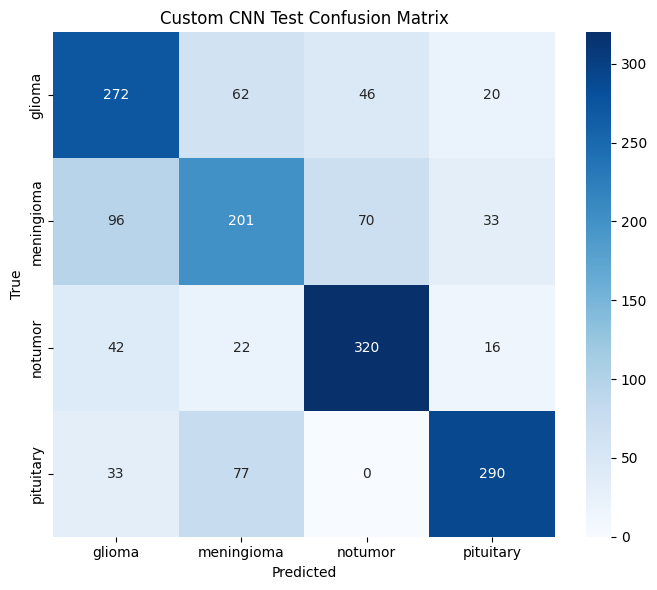

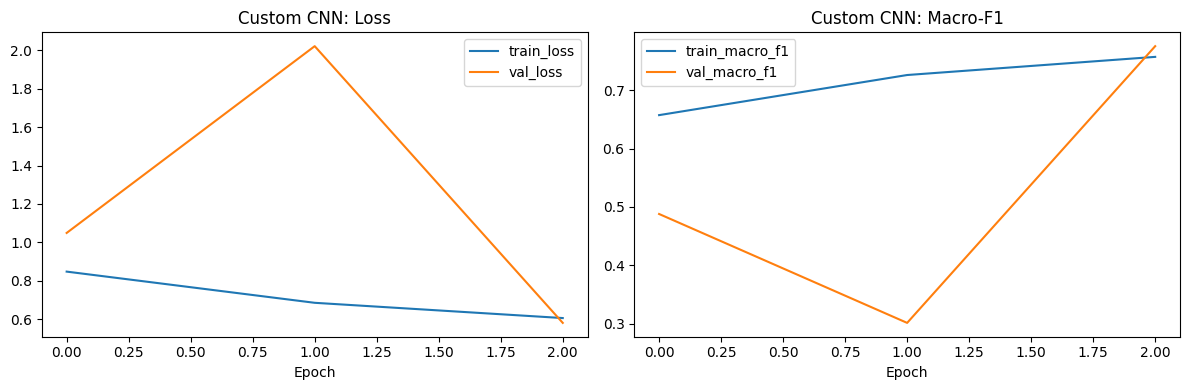

,model,accuracy,macro_precision,macro_recall,macro_f1
0,custom_cnn,0.676875,0.677747,0.676875,0.675647


In [14]:
# Output folder for custom CNN artifacts.
cnn_output_dir = ensure_dir(RESULTS_ROOT / "custom_cnn")

# Build dataloaders with configured image size and batch size.
train_loader, val_loader, test_loader = create_dataloaders(
    split_frames,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=2,
)

# Initialize and train CNN model.
cnn_model = CustomCNN(num_classes=len(split_frames.class_names))
cnn_model, cnn_train_info = train_model(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_names=split_frames.class_names,
    output_dir=cnn_output_dir,
    epochs=EPOCHS,
    learning_rate=1e-3,
)

# Evaluate on held-out test split.
cnn_y_true, cnn_y_pred = predict(cnn_model, test_loader)
cnn_metrics = build_metrics_dict(cnn_y_true, cnn_y_pred, split_frames.class_names)
cnn_metrics["training"] = cnn_train_info
save_json(cnn_metrics, cnn_output_dir / "test_metrics.json")

# Save and display confusion matrix.
cnn_fig = plot_confusion_matrix(
    cnn_y_true,
    cnn_y_pred,
    split_frames.class_names,
    title="Custom CNN Test Confusion Matrix",
)
cnn_fig.savefig(cnn_output_dir / "test_confusion_matrix.png", dpi=150)
plt.show()
plt.close(cnn_fig)

# Show training dynamics.
plot_training_history(cnn_train_info["history"], "Custom CNN")

# Append CNN metrics to final comparison rows.
comparison_rows.append({"model": "custom_cnn", **summarize_for_comparison(cnn_metrics)})
display(pd.DataFrame([comparison_rows[-1]]))

In [15]:
def build_transfer_model(
    model_name: str,
    num_classes: int,
    freeze_backbone: bool = True,
) -> nn.Module:
    # Normalize model name for robust comparisons.
    model_name = model_name.lower()

    # Load pretrained backbone and replace classifier head.
    if model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
    elif model_name == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_features, num_classes)
    else:
        raise ValueError(
            f"Unsupported transfer model '{model_name}'. "
            "Choose from: resnet50, efficientnet_b0, vgg16."
        )

    # Optional head-only warmup by freezing backbone params.
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

        # Keep classifier layers trainable.
        if model_name == "resnet50":
            for param in model.fc.parameters():
                param.requires_grad = True
        elif model_name in {"efficientnet_b0", "vgg16"}:
            for param in model.classifier.parameters():
                param.requires_grad = True

    return model


def unfreeze_last_n_feature_blocks(
    model: nn.Module,
    model_name: str,
    n_blocks: int = 1,
) -> None:
    # Nothing to do if caller requests zero blocks.
    if n_blocks <= 0:
        return

    model_name = model_name.lower()

    # Define deepest-to-shallowest block order per architecture.
    if model_name == "resnet50":
        blocks = [model.layer4, model.layer3, model.layer2, model.layer1]
    elif model_name == "efficientnet_b0":
        blocks = list(model.features)[::-1]
    elif model_name == "vgg16":
        blocks = [model.features]
    else:
        return

    # Unfreeze only the requested number of deep blocks.
    for module in blocks[:n_blocks]:
        for param in module.parameters():
            param.requires_grad = True

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s] 


Head stage epochs: 2
Fine-tune stage epochs: 1


  0%|          | 0/149 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

...

  0%|          | 0/27 [00:00<?, ?it/s]

Epoch 02/2 | train_loss=0.8154 val_loss=0.7998 train_f1=0.7969 val_f1=0.7924


  0%|          | 0/149 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

Epoch 01/1 | train_loss=0.3700 val_loss=0.2780 train_f1=0.8686 val_f1=0.9042


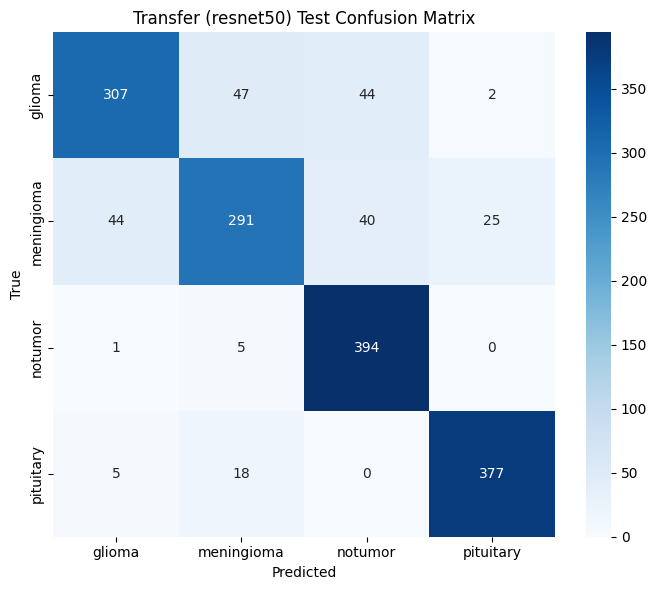

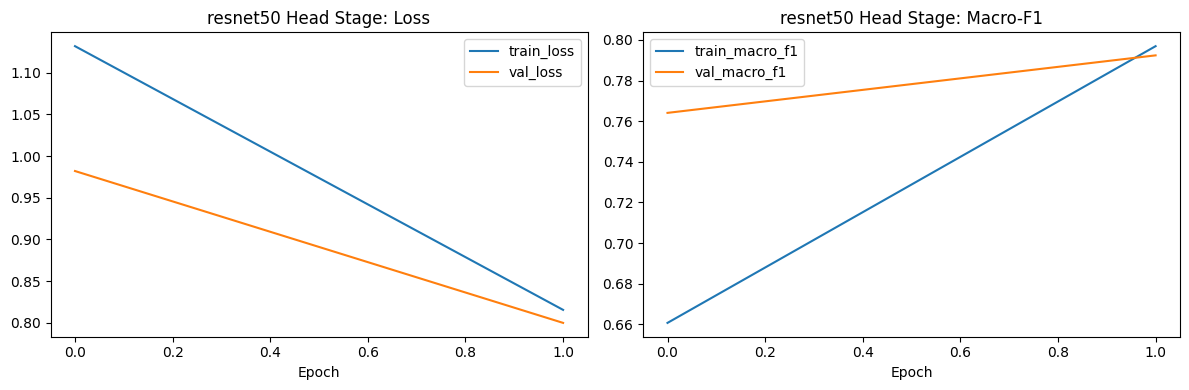

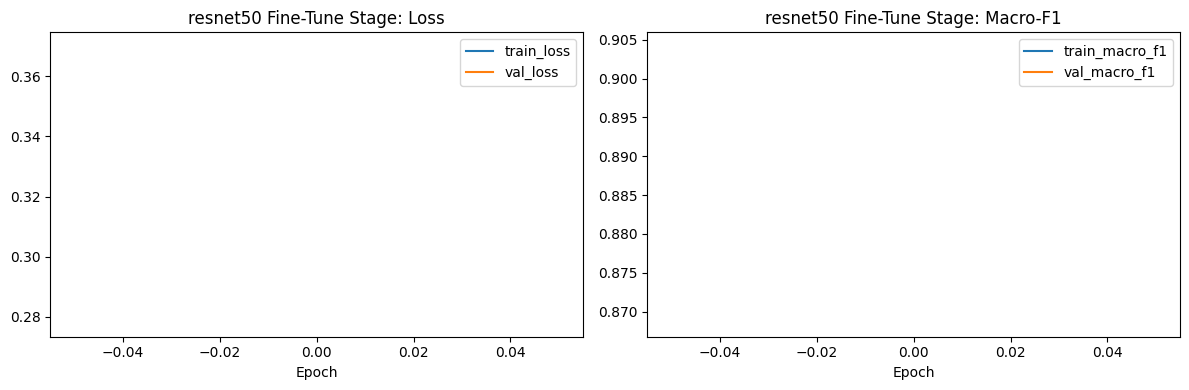

,model,accuracy,macro_precision,macro_recall,macro_f1
0,transfer::resnet50,0.855625,0.855869,0.855625,0.852796


In [16]:
# Output folder for transfer-learning artifacts.
transfer_output_dir = ensure_dir(RESULTS_ROOT / f"transfer_{TRANSFER_MODEL}")

# Recreate loaders so this section is self-contained.
train_loader, val_loader, test_loader = create_dataloaders(
    split_frames,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=2,
)

# Build transfer model with frozen backbone for head warmup.
transfer_model = build_transfer_model(
    model_name=TRANSFER_MODEL,
    num_classes=len(split_frames.class_names),
    freeze_backbone=True,
)

# Split total epochs into warmup and fine-tune stages.
head_stage_epochs = max(2, EPOCHS // 2)
finetune_stage_epochs = max(1, EPOCHS - head_stage_epochs)

print(f"Head stage epochs: {head_stage_epochs}")
print(f"Fine-tune stage epochs: {finetune_stage_epochs}")

# Stage 1: train classifier head with frozen backbone.
transfer_model, head_stage_info = train_model(
    model=transfer_model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_names=split_frames.class_names,
    output_dir=transfer_output_dir / "stage_head",
    epochs=head_stage_epochs,
    learning_rate=2e-4,
)

# Stage 2: unfreeze a deep feature block and fine-tune.
unfreeze_last_n_feature_blocks(transfer_model, model_name=TRANSFER_MODEL, n_blocks=1)
transfer_model, finetune_stage_info = train_model(
    model=transfer_model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_names=split_frames.class_names,
    output_dir=transfer_output_dir / "stage_finetune",
    epochs=finetune_stage_epochs,
    learning_rate=5e-5,
)

# Final test-set evaluation.
transfer_y_true, transfer_y_pred = predict(transfer_model, test_loader)
transfer_metrics = build_metrics_dict(transfer_y_true, transfer_y_pred, split_frames.class_names)
transfer_metrics["training"] = {
    "head_stage": head_stage_info,
    "finetune_stage": finetune_stage_info,
    "head_stage_epochs": head_stage_epochs,
    "finetune_stage_epochs": finetune_stage_epochs,
}
save_json(transfer_metrics, transfer_output_dir / "test_metrics.json")

# Save and display confusion matrix.
transfer_fig = plot_confusion_matrix(
    transfer_y_true,
    transfer_y_pred,
    split_frames.class_names,
    title=f"Transfer ({TRANSFER_MODEL}) Test Confusion Matrix",
)
transfer_fig.savefig(transfer_output_dir / "test_confusion_matrix.png", dpi=150)
plt.show()
plt.close(transfer_fig)

# Plot learning curves for both training stages.
plot_training_history(head_stage_info["history"], f"{TRANSFER_MODEL} Head Stage")
plot_training_history(finetune_stage_info["history"], f"{TRANSFER_MODEL} Fine-Tune Stage")

# Append transfer metrics to final comparison table.
comparison_rows.append(
    {
        "model": f"transfer::{TRANSFER_MODEL}",
        **summarize_for_comparison(transfer_metrics),
    }
)
display(pd.DataFrame([comparison_rows[-1]]))

## Final Model Comparison

,model,accuracy,macro_precision,macro_recall,macro_f1
0,baseline::svm_rbf,0.906875,0.909435,0.906875,0.904905
1,transfer::resnet50,0.855625,0.855869,0.855625,0.852796
2,custom_cnn,0.676875,0.677747,0.676875,0.675647


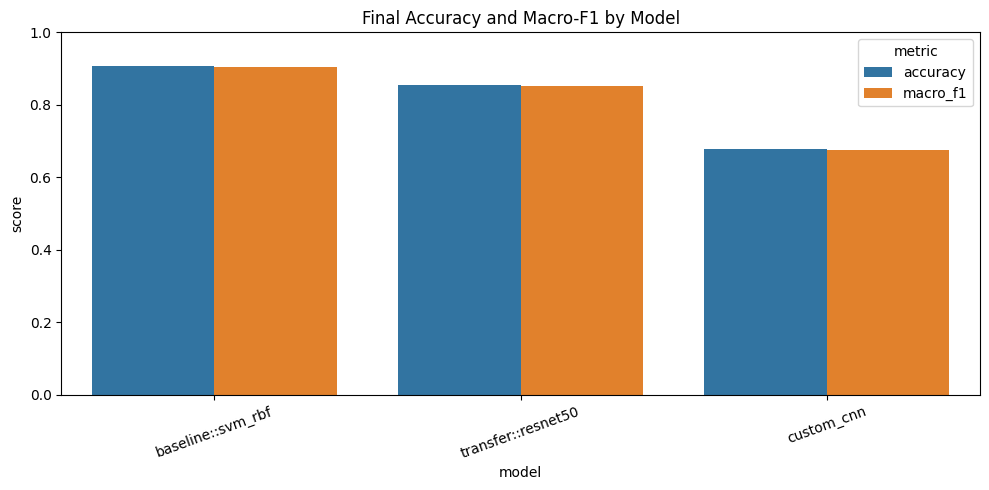


## Key Findings

- Best overall model in this run: **baseline::svm_rbf**
- Best model accuracy: **0.9069**
- Best model macro-F1: **0.9049**
- Full artifacts saved under: `/content/results`

### Saved Outputs
- `/content/results/comparison/model_comparison.csv`
- `/content/results/comparison/model_comparison.json`
- `/content/results/split_report.json`


In [17]:
# Directory for merged comparison artifacts.
comparison_dir = ensure_dir(RESULTS_ROOT / "comparison")

# Sort models by macro-F1 for final ranking.
comparison_df = pd.DataFrame(comparison_rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)

# Save machine-readable and spreadsheet-friendly outputs.
comparison_df.to_csv(comparison_dir / "model_comparison.csv", index=False)
save_json({"models": comparison_rows}, comparison_dir / "model_comparison.json")

# Display final comparison table.
display(Markdown("## Final Model Comparison"))
display(comparison_df)

# Reshape for grouped bar chart plotting.
plot_df = comparison_df.melt(
    id_vars=["model"],
    value_vars=["accuracy", "macro_f1"],
    var_name="metric",
    value_name="score",
)

# Plot accuracy vs macro-F1 by model.
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.ylim(0, 1.0)
plt.xticks(rotation=20)
plt.title("Final Accuracy and Macro-F1 by Model")
plt.tight_layout()
plt.show()

# Build concise markdown summary for report copy/paste.
best_row = comparison_df.iloc[0]
summary_md = f"""
## Key Findings

- Best overall model in this run: **{best_row['model']}**
- Best model accuracy: **{best_row['accuracy']:.4f}**
- Best model macro-F1: **{best_row['macro_f1']:.4f}**
- Full artifacts saved under: `{RESULTS_ROOT}`

### Saved Outputs
- `{comparison_dir / 'model_comparison.csv'}`
- `{comparison_dir / 'model_comparison.json'}`
- `{RESULTS_ROOT / 'split_report.json'}`
"""
display(Markdown(summary_md))

In [18]:
# Optional: zip all outputs for easy submission/download.
import importlib.util
import shutil

# Create a zip archive of the full results folder.
archive_base = Path("/content/brain_tumor_mri_results")
archive_file = shutil.make_archive(str(archive_base), "zip", RESULTS_ROOT)
print(f"Created archive: {archive_file}")

# Check whether the Colab module is available before importing.
in_colab = importlib.util.find_spec("google.colab") is not None
if in_colab:
    from google.colab import files

    # Uncomment to download directly in Colab.
    # files.download(archive_file)
    print("Colab environment detected. Uncomment files.download(...) to download the zip.")
else:
    print("Colab module not detected; archive is still available on disk.")

Created archive: /content/brain_tumor_mri_results.zip
Colab environment detected. Uncomment files.download(...) to download the zip.
